# Sign conventions for beam loads

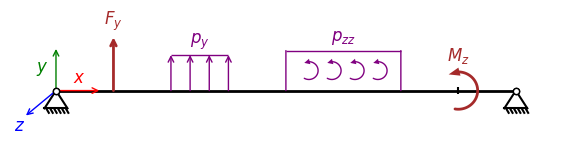

In [7]:
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib import patheffects
import matplotlib.pyplot as plt


def get_max_zorder(ax):
    return max([_.zorder for _ in ax.get_children()])


def add_concentrated_bending_moment(
    ax,
    x, y,
    radius=0.45,
    theta1=-90,
    theta2=90,
    direction="cw",
    color="brown",
    linewidth=2.5,
    head_length=10,
    head_width=8,
    n=80,
    head_arc_deg=10.0,      # <- reserve this many degrees for the arrowhead
    label=None,
    label_offset=(0.0, 0.08),
    tick_size=0.15,
    tick_width=1.5,
):
    t1 = np.deg2rad(theta1)
    t2 = np.deg2rad(theta2)

    # Reserve a small angle for the arrowhead so the tip reaches the arc end visually
    dth = np.deg2rad(head_arc_deg)

    if direction.lower() == "cw":
        # head at theta2, so stop arc early at (theta2 - dth)
        ts_arc = np.linspace(t1, t2 - dth, n)
        th_end = t2
        th_prev = t2 - dth
    elif direction.lower() == "ccw":
        # head at theta1, so start arc late at (theta1 + dth)
        ts_arc = np.linspace(t1 + dth, t2, n)
        th_end = t1
        th_prev = t1 + dth
    else:
        raise ValueError("direction must be 'cw' or 'ccw'")

    # Arc polyline (no head)
    xs = x + radius * np.cos(ts_arc)
    ys = y + radius * np.sin(ts_arc)
    ax.plot(xs, ys, color=color, linewidth=linewidth, solid_capstyle="round", zorder=5)

    # Arrowhead: tangent segment over the reserved angle
    end = np.array([x + radius * np.cos(th_end),  y + radius * np.sin(th_end)])
    prev = np.array([x + radius * np.cos(th_prev), y + radius * np.sin(th_prev)])

    head = FancyArrowPatch(
        prev, end,
        arrowstyle=f"-|>,head_length={head_length},head_width={head_width}",
        linewidth=0,
        facecolor=color,
        edgecolor=color,
        shrinkA=0, shrinkB=0,
        zorder=6,
    )
    ax.add_patch(head)
    
    # vertical tick on the beam, at the point of application
    if tick_size and tick_size > 0:
        ax.plot(
            [xM, xM],
            [-tick_size/2, tick_size/2],
            color='black',
            linewidth=tick_width,
            solid_capstyle='butt'
        )

    if label:
        ax.text(
            x + label_offset[0],
            y + radius + label_offset[1],
            label,
            ha="center",
            va="bottom",
            color=color,
            fontsize=12
        )

    return head


def add_hinge(ax, x, y, s=20, fc='white', ec='k', lw=1, zorder=None, **kwargs):
    if zorder is None:
        zorder = get_max_zorder(ax) + 1
    ax.scatter(x, y, s=s, fc=fc, ec=ec, lw=lw, alpha=1.0, zorder=zorder, **kwargs)


def add_triangle_support(ax, xy, w, h, hinge_params={}):
    x = [xy[0] - w/2, xy[0] + w/2]
    y = [xy[1] - h, xy[1] -h]
    spec = [patheffects.withTickedStroke(angle=-60, spacing=2.5, length=1.5)]
    ax.plot(x, y, color='k', path_effects=spec)
    x = [xy[0] - w/2, xy[0], xy[0] + w/2]
    y = [xy[1] - h, xy[1], xy[1] -h]
    ax.plot(x, y, color='k')
    add_hinge(ax, xy[0], xy[1], **hinge_params)


fig, ax = plt.subplots(figsize=(7.12, 1.5))
beam_length = 10.0

# Draw the beam as a thick line
ax.plot([0, beam_length], [0, 0], color='black', linewidth=2, solid_capstyle='butt')

# x axis
ax.annotate(
    "",
    xy=(1, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='r'),
    fontsize=10
)
ax.text(
    0.5,
    0.1,
    r"$x$",
    ha="center",
    va="bottom",
    color="r",
    fontsize=12
)

# y axis
ax.annotate(
    "",
    xy=(0, 1),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='g'),
    fontsize=10
)
ax.text(
    -0.3,
    0.3,
    r"$y$",
    ha="center",
    va="bottom",
    color="g",
    fontsize=12
)

# z axis
ax.annotate(
    "",
    xy=(-0.7, -0.6),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='b'),
    fontsize=10
)
ax.text(
    -0.8,
    -1.0,
    r"$z$",
    ha="center",
    va="bottom",
    color="b",
    fontsize=12
)

# distributed vertical load
distributed_load_height = 0.8
distributed_load_x0 = 2 * beam_length / 8
distributed_load_x1 = 3 * beam_length / 8
ax.plot(
    [distributed_load_x0, distributed_load_x1], 
    [distributed_load_height, distributed_load_height], 
    color='purple', 
    linewidth=1, 
    solid_capstyle='butt'
)
for i in range(4):
    ax.annotate(
        "",
        xy=(distributed_load_x0 + i*(distributed_load_x1 - distributed_load_x0)/3, distributed_load_height),
        xytext=(distributed_load_x0 + i*(distributed_load_x1 - distributed_load_x0)/3, 0),
        arrowprops=dict(arrowstyle='->', color='purple', shrinkA=0, shrinkB=0),
        fontsize=10,
    )
ax.text(
    (distributed_load_x0 + distributed_load_x1) / 2,
    distributed_load_height + 0.08,
    r"$p_y$",
    ha="center",
    va="bottom",
    color="purple",
    fontsize=12
)

# distributed moment load
distributed_load_height = 0.9
distributed_load_x0 = 4 * beam_length / 8
distributed_load_x1 = 6 * beam_length / 8
ax.plot(
    [distributed_load_x0, distributed_load_x1], 
    [distributed_load_height, distributed_load_height], 
    color='purple', 
    linewidth=1, 
    solid_capstyle='butt'
)
for i in range(2):
    ax.annotate(
        "",
        xy=(distributed_load_x0 + i*(distributed_load_x1 - distributed_load_x0)/1, distributed_load_height),
        xytext=(distributed_load_x0 + i*(distributed_load_x1 - distributed_load_x0)/1, 0),
        arrowprops=dict(arrowstyle='-', color='purple', shrinkA=0, shrinkB=0),
        fontsize=10,
    )
for i in range(1, 5):
    xM = distributed_load_x0 + i*(distributed_load_x1 - distributed_load_x0)/5
    moment_tick_size = 0.15
    add_concentrated_bending_moment(
        ax,
        x=xM, y=0.45,           # slightly above beam
        radius=0.2,
        theta1=-120, theta2=120,  # near-semicircle
        direction="cw",         # makes the head appear on the left like your screenshot
        color="purple",
        linewidth=1.0,
        head_length=4,
        head_width=2,
        head_arc_deg=30,
        tick_size=None,
    )
ax.text(
    (distributed_load_x0 + distributed_load_x1) / 2,
    distributed_load_height + 0.08,
    r"$p_{zz}$",
    ha="center",
    va="bottom",
    color="purple",
    fontsize=12
)

# concentrated load
xF = beam_length / 8
concentrated_load_height = 1.2
ax.annotate(
    "",
    xy=(xF, concentrated_load_height),
    xytext=(xF, 0),
    arrowprops=dict(arrowstyle='->', color='brown', linewidth=2, shrinkA=0, shrinkB=0),
    fontsize=10,
)
ax.text(
    xF,
    concentrated_load_height + 0.1,
    r"$F_y$",
    ha="center",
    va="bottom",
    color="brown",
    fontsize=12
)

# Concentrated moment
xM = 7 * beam_length / 8
moment_tick_size = 0.15
add_concentrated_bending_moment(
    ax,
    x=xM, y=0.0,           # slightly above beam
    radius=0.42,
    theta1=-100, theta2=120,  # near-semicircle
    direction="cw",         # makes the head appear on the left like your screenshot
    color="brown",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
    label=r"$M_z$",
    label_offset=(0.0, 0.15),
    tick_size=moment_tick_size
)

add_triangle_support(ax, (0, 0), 0.5, 0.4)
add_hinge(ax, 0, 0)

add_triangle_support(ax, (beam_length, 0), 0.5, 0.4)
add_hinge(ax, beam_length, 0)

# formatting
ax.set_xlim(-1, beam_length + 1)
ax.set_ylim(-1, 1.6)
ax.axis('off')
plt.show()

# # save figure
# fig.savefig("../_static/simply_supported_beam_example_1.pdf", format="pdf")
# fig.savefig("../_static/simply_supported_beam_example_1_light.png", format="png")

In [8]:
from helper_utils import save_png_images

save_png_images(fig, "sign_convention_beam_XY_load")

Saved light mode image to: ../_static/sign_convention_beam_XY_load_light.png
Saved dark mode image to: ../_static/sign_convention_beam_XY_load_dark.png
